In [ ]:
import pandas as pd
import numpy as np
import random
from google.colab import drive

# Step 0: Install required packages
!pip install networkx matplotlib numpy pandas scikit-learn

# Step 1: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/maternal.csv")







In [ ]:
# Features and labels
X = df.drop(["ID","target"], axis=1)
y = df["target"]

# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

#

Dataset size: 1014
Train size: 811
Test size: 203


In [ ]:
df.describe()


,ID,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,target
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,507.500000,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,0.867850
std,292.860888,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,0.807353
min,1.000000,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,0.000000
25%,254.250000,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,0.000000
50%,507.500000,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,1.000000
75%,760.750000,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,2.000000
max,1014.000000,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,2.000000


In [ ]:
X.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate'], dtype='object')

In [ ]:
#---------------------------
# Step 3: Direct ML (for feature importance)
# ---------------------------
rf_direct = RandomForestClassifier(random_state=42)
rf_direct.fit(X_train, y_train)
y_pred_direct = rf_direct.predict(X_test)

print("\n=== Direct ML Metrics ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))




=== Direct ML Metrics ===
Accuracy: 0.8522167487684729
Precision: 0.851993927473478
Recall: 0.8522167487684729
F1 Score: 0.8514397128335885
Confusion Matrix:
 [[66 14  1]
 [ 8 54  5]
 [ 2  0 53]]


In [ ]:
display(df['target'].value_counts())

,count
target,
0,406
1,336
2,272


In [ ]:
# Compute feature importance
feature_importances = pd.Series(rf_direct.feature_importances_, index=X_train.columns)
filter_attributes = feature_importances.sort_values(ascending=False).index.tolist()
print("\nFilter attributes by importance:", filter_attributes)

#


Filter attributes by importance: ['BS', 'SystolicBP', 'Age', 'DiastolicBP', 'HeartRate', 'BodyTemp']


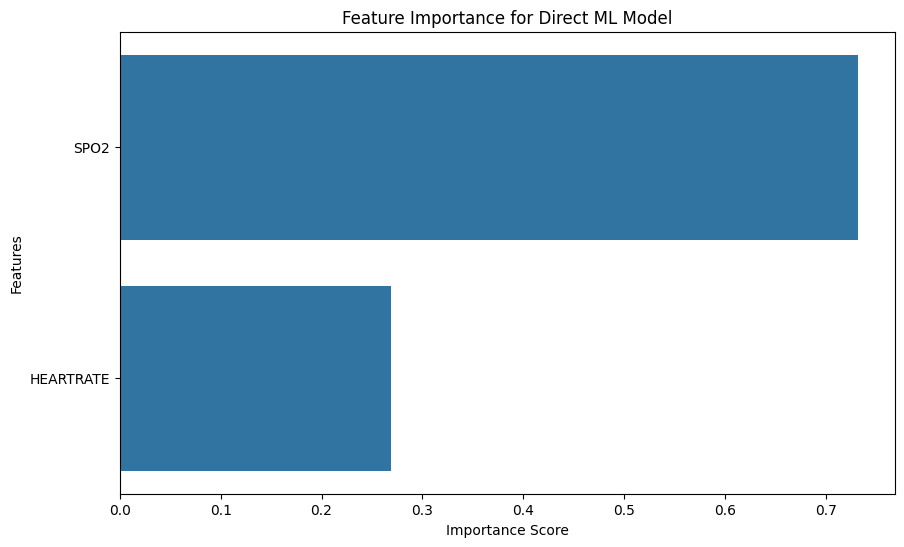

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort feature importances for visualization
feature_importances = feature_importances.sort_values(ascending=False)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Feature Importance for Direct ML Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/maternal.csv")


# Features and labels
X = df.drop(["target"], axis=1)
y = df["target"]

# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

# ---------------------------
# Step 3: Direct ML (Initial run for feature importance - for reference)
# ---------------------------
rf_direct_initial = RandomForestClassifier(random_state=42)
rf_direct_initial.fit(X_train, y_train)
importances = rf_direct_initial.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
# top_features = feat_imp.head(10).index.tolist()  # Keep top 10 features

# Use only the features specified by the user
top_features = [ 'BS','SystolicBP','Age']
print("Selected filter attributes:", top_features)


# Filter X_train and X_test to keep only top features
X_train_filtered = X_train[top_features]
X_test_filtered = X_test[top_features]


# ---------------------------
# Step 4: Direct ML (with filtered features)
# ---------------------------
rf_direct = RandomForestClassifier(n_estimators=5, random_state=42)
rf_direct.fit(X_train_filtered, y_train)
y_pred_direct = rf_direct.predict(X_test_filtered)

print("\n=== Direct ML Metrics (Filtered Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))

# ---------------------------
# Step 5: Prepare data for Reeb graph (using filtered features)
# ---------------------------
train_df = X_train_filtered.copy()
train_df["Class"] = y_train


Dataset size: 1014
Train size: 811
Test size: 203
Selected filter attributes: ['BS', 'SystolicBP', 'Age']

=== Direct ML Metrics (Filtered Features) ===
Accuracy: 0.8029556650246306
Precision: 0.8039226318124842
Recall: 0.8029556650246306
F1 Score: 0.803335989568241
Confusion Matrix:
 [[65 15  1]
 [11 50  6]
 [ 3  4 48]]


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the correlation matrix of the augmented training data
plt.figure(figsize=(12, 8))
sns.heatmap(results["df_aug_train"].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Augmented Training Data")
plt.show()

# Visualize feature importance of the hybrid RF model
# Get feature importances from the hybrid RF model
feature_importances_hybrid = pd.Series(results["rf_hybrid"].feature_importances_, index=results["df_aug_train"].columns)

# Sort feature importances for visualization
feature_importances_hybrid = feature_importances_hybrid.sort_values(ascending=False)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_hybrid.values, y=feature_importances_hybrid.index)
plt.title("Feature Importance for Hybrid RF Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

NameError: name 'results' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:
#  (multi-D clustering, medoids, SMOTE, k-NN mapping, hybrid RF)
# Requires: numpy, pandas, sklearn, imblearn
# Example usage at bottom.

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings("ignore")


def choose_best_k(data_2d, k_min=2, k_max=6, random_state=42):
    """Choose best k using silhouette score. Returns (best_k, labels, centers) or (None, None, None)."""
    best_k = None
    best_score = -1
    best_labels = None
    best_centers = None
    n_samples = data_2d.shape[0]
    if n_samples < k_min:
        return None, None, None
    k_max = min(k_max, n_samples)
    for k in range(k_min, k_max + 1):
        try:
            km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            labels = km.fit_predict(data_2d)
            if len(np.unique(labels)) < 2:
                continue
            score = silhouette_score(data_2d, labels)
            if score > best_score:
                best_score = score
                best_k = k
                best_labels = labels
                best_centers = km.cluster_centers_
        except Exception:
            continue
    return best_k, best_labels, best_centers


def medoid_of_group(X_group):
    """
    Return medoid index and medoid vector for a DataFrame/2D-array X_group.
    Medoid = row with minimum sum of distances to others (or to centroid if faster).
    """
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    # compute centroid then pick sample closest to centroid (fast, robust)
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]


def merge_small_clusters(labels, cluster_centers, min_samples, data_2d):
    """
    Merge clusters that have <min_samples with nearest larger cluster.
    Returns new labels (np.array) and possibly updated centers (not re-computed here).
    """
    labels = labels.copy()
    unique = np.unique(labels)
    # get cluster sizes
    sizes = {u: np.sum(labels == u) for u in unique}
    # If all clusters are >= min_samples, nothing to do
    small = [u for u, s in sizes.items() if s < min_samples]
    if not small:
        return labels

    # compute centers if not given:
    centers = np.asarray(cluster_centers)
    for s in small:
        small_idx = np.where(labels == s)[0]
        if len(small_idx) == 0:
            continue
        # find closest other cluster center
        d_to_centers = np.linalg.norm(centers - centers[s], axis=1)
        # exclude itself
        d_to_centers[s] = np.inf
        nearest = int(np.argmin(d_to_centers))
        # reassign labels of small cluster to 'nearest'
        labels[labels == s] = nearest

    # optionally compress labels so they are contiguous (not necessary)
    unique_after = np.unique(labels)
    mapping = {old: new for new, old in enumerate(unique_after)}
    new_labels = np.array([mapping[l] for l in labels])
    return new_labels


def cluster_and_recurse(df, attrs, min_samples=10, max_bins=6, k_features=2, depth=0, max_depth=10, random_state=42):
    """
    Recursively cluster on top k_features (attributes) jointly, adaptively choose k using silhouette,
    merge small clusters, and preserve small clusters rather than discarding them (we return them as leaf groups).
    Returns a list of leaf DataFrames.
    """
    # termination conditions
    if depth >= max_depth or len(attrs) == 0 or len(df) < min_samples:
        return [df] if len(df) >= 1 else []

    # choose feature subset for clustering at this level
    use_attrs = attrs[:k_features] if len(attrs) >= k_features else attrs
    data_for_clustering = df[use_attrs].values

    # standardize before clustering (important for mixed-scale features)
    scaler = StandardScaler()
    try:
        data_scaled = scaler.fit_transform(data_for_clustering)
    except Exception:
        data_scaled = data_for_clustering.copy()

    # If we have more than 2 dims, reduce to 2D for silhouette + KMeans stability
    if data_scaled.shape[1] > 2:
        pca = PCA(n_components=2, random_state=random_state)
        try:
            proj = pca.fit_transform(data_scaled)
        except Exception:
            proj = data_scaled[:, :2]
    else:
        proj = data_scaled

    # adaptive k
    best_k, best_labels, centers = choose_best_k(proj, k_min=2, k_max=max_bins, random_state=random_state)
    #print("Best_k, best labels, centers",best_k, best_labels, centers)
    if best_k is None:
        # cannot cluster meaningfully -> treat current df as leaf
        return [df]

    # merge small clusters
    labels_merged = merge_small_clusters(best_labels, centers, min_samples, proj)

    leaf_nodes = []
    for label in np.unique(labels_merged):
        sub_df = df[labels_merged == label]
        if len(sub_df) >= min_samples:
            # Recurse on remaining attributes (drop the used attrs to encourage variety)
            next_attrs = attrs.copy()
            # Option: rotate attrs so we do not repeatedly split on same attributes
            # Here we simply use attrs[1:] to keep behavior similar to previous approach but with multi-D
            if len(next_attrs) > 1:
                next_attrs = next_attrs[1:]
            leaf_nodes.extend(cluster_and_recurse(sub_df, next_attrs, min_samples, max_bins,
                                                  k_features=k_features, depth=depth+1, max_depth=max_depth,
                                                  random_state=random_state))
        else:
            # preserve minority cluster as a leaf (do not discard)
            leaf_nodes.append(sub_df)

    return leaf_nodes


def apply_smote_inside_group(group_df, feature_cols, class_col="Class", smote_min_size=6, random_state=42):
    """
    Apply SMOTE only if group has more than one class and size >= smote_min_size.
    Returns new group dataframe (possibly unchanged on failure).
    """
    if len(group_df) < smote_min_size:
        return group_df
    y = group_df[class_col]
    if len(y.unique()) < 2:
        return group_df
    X = group_df[feature_cols]
    try:
        sm = SMOTE(random_state=random_state, k_neighbors=min(5, len(group_df)-1))
        X_res, y_res = sm.fit_resample(X.values, y.values)
        df_new = pd.DataFrame(X_res, columns=feature_cols)
        df_new[class_col] = y_res
        return df_new
    except Exception:
        return group_df


def create_reeb_nodes_from_leaf_groups(leaf_groups, feature_cols, class_col="Class", apply_smote_flag=True):
    """
    For each leaf group:
     - optionally apply SMOTE,
     - compute medoid prototype,
     - compute soft class distribution,
     - store node info
    Returns: reeb_df (DataFrame of prototypes + hard label), node_list (list of dicts with metadata)
    """
    nodes = []
    for grp in leaf_groups:
        if len(grp) == 0:
            continue
        # ensure we are working on a fresh copy
        group = grp.copy().reset_index(drop=True)
        if apply_smote_flag:
            group = apply_smote_inside_group(group, feature_cols, class_col=class_col)

        # medoid selection
        medoid_idx, medoid_vec = medoid_of_group(group[feature_cols].values)
        medoid_series = group[feature_cols].iloc[medoid_idx].values

        # soft label distribution
        dist = group[class_col].value_counts(normalize=True).to_dict()
        # majority class
        majority = max(dist.items(), key=lambda x: x[1])[0]

        node = {
            "medoid_features": medoid_series,
            "majority_class": majority,
            "class_distribution": dist,
            "group_size": len(group)
        }
        nodes.append(node)

    # Build reeb_df for hard-label training if nodes exist
    if len(nodes) == 0:
        return None, []

    reeb_df = pd.DataFrame([list(n["medoid_features"]) + [n["majority_class"]] for n in nodes],
                           columns=list(feature_cols) + [class_col])
    return reeb_df, nodes


def compute_node_distances(X_df, nodes, feature_cols):
    """
    Compute distances from each sample in X_df to every node medoid.
    Returns a 2D numpy array (n_samples x n_nodes).
    """
    if nodes is None or len(nodes) == 0:
        return np.zeros((len(X_df), 0))
    node_feats = np.vstack([n["medoid_features"] for n in nodes])
    X_arr = X_df[feature_cols].values
    # pairwise distances (euclidean)
    dists = np.linalg.norm(X_arr[:, None, :] - node_feats[None, :, :], axis=2)
    return dists


def map_test_samples_to_nodes(X_test_df, nodes, feature_cols, k_nodes=3):
    """
    Map test samples to k nearest reeb nodes and produce predicted class using
    distance-weighted vote across node class distributions.
    Returns a list/array of predicted class labels.
    """
    if nodes is None or len(nodes) == 0:
        # no nodes => cannot map; return None so caller can fallback
        return None

    dists = compute_node_distances(X_test_df, nodes, feature_cols)  # shape (n_samples, n_nodes)
    n_nodes = dists.shape[1]
    # For each test sample:
    preds = []
    for i in range(dists.shape[0]):
        # indices of nearest nodes
        k = min(k_nodes, n_nodes)
        nearest_idx = np.argsort(dists[i])[:k]
        # Weighted vote using inverse distance (add small epsilon)
        eps = 1e-8
        weights = 1.0 / (dists[i][nearest_idx] + eps)
        # aggregate class distributions
        agg = {}
        for idx, w in zip(nearest_idx, weights):
            node = nodes[idx]
            for cls, prob in node["class_distribution"].items():
                agg[cls] = agg.get(cls, 0.0) + w * prob
        # choose class with max aggregate score
        if len(agg) == 0:
            preds.append(nodes[nearest_idx[0]]["majority_class"])
        else:
            pred = max(agg.items(), key=lambda x: x[1])[0]
            preds.append(pred)
    return np.array(preds)


def train_hybrid_rf(X_train_df, y_train_series, nodes, feature_cols, n_estimators=200, random_state=42):
    """
    Train RandomForest on raw features augmented with distances to node medoids.
    Returns trained RF and the augmented training DataFrame used.
    """
    # compute distances features
    dists_train = compute_node_distances(X_train_df, nodes, feature_cols)  # shape (n_samples, n_nodes)
    # create column names for distances
    dist_cols = [f"dist_node_{i}" for i in range(dists_train.shape[1])]
    df_aug = X_train_df.copy().reset_index(drop=True)
    for i, col in enumerate(dist_cols):
        df_aug[col] = dists_train[:, i]

    # RF with class_weight balanced to handle class imbalance
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, class_weight='balanced')
    rf.fit(df_aug.values, y_train_series.values)
    return rf, df_aug, dist_cols


def evaluate_predictions(y_true, y_pred, average='weighted'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average)
    f1 = f1_score(y_true, y_pred, average=average)
    cm = confusion_matrix(y_true, y_pred)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm}


# -------------------------
# Example pipeline orchestration
# -------------------------
def reeb_pipeline(X_train_filtered, y_train, X_test_filtered, y_test,
                  top_features=None,
                  min_samples=10,
                  max_bins=6,
                  k_features=2,
                  k_map_nodes=3,
                  apply_smote_flag=True,
                  max_depth=10,
                  random_state=42):
    """
    Run the whole improved Reeb pipeline and evaluate.
    Returns a dict with models, nodes, predictions and metrics.
    """
    if top_features is None:
        top_features = list(X_train_filtered.columns)

    # prepare train_df with class column for clustering
    train_df = X_train_filtered.copy().reset_index(drop=True)
    train_df["Class"] = y_train.reset_index(drop=True)

    # Step A: hierarchical clustering to obtain leaf groups
    print("Generating leaf groups with multi-D adaptive clustering...")
    leaf_groups = cluster_and_recurse(train_df, top_features.copy(), min_samples=min_samples,
                                      max_bins=max_bins, k_features=k_features,
                                      max_depth=max_depth, random_state=random_state)
    print(f"Number of leaf groups obtained: {len(leaf_groups)}")

    # Step B: create reeb nodes from leaf groups (medoid, soft labels, optional SMOTE)
    print("Creating Reeb nodes (medoids + soft labels + optional SMOTE inside groups)...")
    reeb_df, nodes = create_reeb_nodes_from_leaf_groups(leaf_groups, feature_cols=top_features,
                                                        class_col="Class", apply_smote_flag=apply_smote_flag)
    if nodes is None or len(nodes) == 0:
        print("Warning: no Reeb nodes could be created. Falling back to standard RF on raw data.")
        # fallback RF on raw features
        rf_fallback = RandomForestClassifier(n_estimators=5, random_state=random_state, class_weight='balanced')
        rf_fallback.fit(X_train_filtered.values, y_train.values)
        y_pred_fb = rf_fallback.predict(X_test_filtered.values)
        metrics_fb = evaluate_predictions(y_test, y_pred_fb)
        return {
            "nodes": [],
            "reeb_df": None,
            "rf_model": rf_fallback,
            "y_pred": y_pred_fb,
            "metrics": metrics_fb
        }

    print(f"Created {len(nodes)} Reeb nodes. Sample node sizes: {[n['group_size'] for n in nodes[:10]]}")

    # Step C: Train hybrid RF on raw + distances to nodes
    print("Training hybrid RandomForest on raw features augmented with distances to node medoids...")
    rf_hybrid, df_aug_train, dist_cols = train_hybrid_rf(X_train_filtered, y_train, nodes, top_features,
                                                         n_estimators=300, random_state=random_state)

    # Step D: Map test samples using k-NN mapping to nodes (distance-weighted) -> predictions_map
    print(f"Mapping test samples to {k_map_nodes} nearest nodes and producing node-based predictions...")
    preds_node_map = map_test_samples_to_nodes(X_test_filtered, nodes, top_features, k_nodes=k_map_nodes)

    # Step E: Also predict using hybrid RF by augmenting test with distance features
    print("Augmenting test features with distances to nodes for hybrid RF prediction...")
    dists_test = compute_node_distances(X_test_filtered, nodes, top_features)
    df_aug_test = X_test_filtered.copy().reset_index(drop=True)
    for i, col in enumerate([f"dist_node_{i}" for i in range(dists_test.shape[1])]):
        df_aug_test[col] = dists_test[:, i]

    y_pred_hybrid = rf_hybrid.predict(df_aug_test.values)

    # Evaluate both node-mapping and hybrid RF
    print("Evaluating node-mapping predictions (distance-weighted k-NN to nodes)...")
    metrics_nodes = None
    if preds_node_map is not None:
        metrics_nodes = evaluate_predictions(y_test, preds_node_map)

    print("Evaluating hybrid RF predictions (raw features + node-distances)...")
    metrics_hybrid = evaluate_predictions(y_test, y_pred_hybrid)

    # Aggregate results
    results = {
        "nodes": nodes,
        "reeb_df": reeb_df,
        "rf_hybrid": rf_hybrid,
        "y_pred_node_map": preds_node_map,
        "metrics_node_map": metrics_nodes,
        "y_pred_hybrid": y_pred_hybrid,
        "metrics_hybrid": metrics_hybrid,
        "df_aug_train": df_aug_train,
        "df_aug_test": df_aug_test
    }

    print("Done.")
    return results


# -------------------------
# Minimal example of how to call (uncomment & adapt to your variable names)
# -------------------------
# Example usage (assuming you have X_train_filtered, y_train, X_test_filtered, y_test defined):
#
results = reeb_pipeline(
     X_train_filtered=X_train_filtered,
     y_train=y_train,
     X_test_filtered=X_test_filtered,
     y_test=y_test,
     top_features=top_features,   # list of feature column names
     min_samples=8,
     max_bins=6,
     k_features=3,
     k_map_nodes=3,
     apply_smote_flag=True,
     max_depth=8,
     random_state=42
 )

print("Hybrid RF metrics:", results["metrics_hybrid"])
if results["metrics_node_map"] is not None:
     print("Node-mapping metrics:", results["metrics_node_map"])
#
# You can inspect results["nodes"] to see medoid prototypes and class distributions.


Generating leaf groups with multi-D adaptive clustering...
Number of leaf groups obtained: 63
Creating Reeb nodes (medoids + soft labels + optional SMOTE inside groups)...
Created 63 Reeb nodes. Sample node sizes: [51, 17, 10, 13, 13, 11, 8, 19, 6, 2]
Training hybrid RandomForest on raw features augmented with distances to node medoids...
Mapping test samples to 3 nearest nodes and producing node-based predictions...
Augmenting test features with distances to nodes for hybrid RF prediction...
Evaluating node-mapping predictions (distance-weighted k-NN to nodes)...
Evaluating hybrid RF predictions (raw features + node-distances)...
Done.
Hybrid RF metrics: {'accuracy': 0.8226600985221675, 'precision': 0.8230541846243639, 'recall': 0.8226600985221675, 'f1': 0.8215286745454365, 'confusion_matrix': array([[63, 15,  3],
       [ 9, 52,  6],
       [ 2,  1, 52]])}
Node-mapping metrics: {'accuracy': 0.6600985221674877, 'precision': 0.6654023772804374, 'recall': 0.6600985221674877, 'f1': 0.660

Where limitations show

Very high-dimensional datasets (e.g., text, images)

PCA down to 2D loses too much structure; deep embeddings may be needed before your pipeline.

Tiny datasets

SMOTE requires at least a few minority samples; oversampling may fail if groups are very small.

Perfectly balanced, linearly separable datasets

Your method may be “over-engineered” compared to simpler classifiers (like logistic regression or SVM).

Streaming or non-stationary data

Recursive binning + static medoid prototypes assume stationarity; not directly suited for evolving data without modification.